# <center>Factor Regressions</center>

$$ R_t - R_{f,t} = \alpha + \beta_1(Mkt\text{-}Rf)_t + \beta_2(SMB)_t + \beta_3(HML)_t + \beta_4(RMW)_t + \beta_5(CMA)_t + \beta_6(MOM)_t + \epsilon_t $$

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import getFamaFrenchFactors as gff

In [2]:
rets = yf.download(['VTI', 'VLUE', 'MTUM'], interval='1mo', start='1900-01-01', auto_adjust=True)['Close']
rets = rets.to_period('M').pct_change().dropna()

[*********************100%***********************]  3 of 3 completed


In [3]:
ff_5_factor_model = gff.famaFrench5Factor().set_index('date_ff_factors').to_period('M')
ff_momentum_factor = gff.momentumFactor().set_index('date_ff_factors').to_period('M')

ff_6_factor_model = ff_5_factor_model.join(ff_momentum_factor)
ff_6_factor_model = ff_6_factor_model[[*ff_6_factor_model.columns.drop('RF'), 'RF']]

In [4]:
def factor_regression(rets, factor_model):
    # common index
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    # prep data for regression
    rets_excess = rets - factor_model[['RF']].values
    factor_model_minus_RF = factor_model[[*ff_6_factor_model.columns.drop('RF')]]
    factor_model_minus_RF['Alpha'] = 1

    # run regression
    lm = sm.OLS(rets_excess, factor_model_minus_RF).fit()
    factor_loadings = lm.params
    factor_loadings.columns = rets.columns

    # calculate annualized alpha
    alpha_per_period = factor_loadings.loc[['Alpha']]
    annualized_alpha = ((1+alpha_per_period)**12)-1
    annualized_alpha.index = ['Annualized Alpha']
    factor_loadings = pd.concat([factor_loadings, annualized_alpha])

    # alpha & annualized alpha in %
    factor_loadings = factor_loadings.round(2)
    factor_loadings = factor_loadings.astype(object)
    factor_loadings.loc[['Alpha']] = (alpha_per_period * 100).round(2).astype(str) + '%'
    factor_loadings.loc[['Annualized Alpha']] = (annualized_alpha * 100).round(2).astype(str) + '%'

    return factor_loadings

In [5]:
factor_regression(rets, ff_6_factor_model)

Ticker,MTUM,VLUE,VTI
Mkt-RF,1.08,1.0,1.01
SMB,-0.11,0.06,-0.03
HML,-0.03,0.43,0.04
RMW,-0.08,0.01,0.02
CMA,0.05,0.01,-0.03
MOM,0.39,-0.05,0.01
Alpha,-0.1%,-0.11%,-0.05%
Annualized Alpha,-1.23%,-1.26%,-0.56%


In [6]:
def rolling_factor_regression(rets, factor_model, roll_window=36):
    # common index
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    # prep data for regression
    rets_excess = rets - factor_model[['RF']].values
    factor_model_minus_RF = factor_model[[*ff_6_factor_model.columns.drop('RF')]]

    # rolling
    n_periods = rets.shape[0]
    windows = [(start, start + roll_window) for start in range(n_periods - roll_window + 1)]

    if n_periods <= roll_window:
        print('Sample smaller than roll window.')
        return
    
    # rolling regression
    results = {}
    for ret_excess in rets_excess:
        factor_loadings_per_window = []
        for win in windows:
            lm = sm.OLS(rets_excess[ret_excess].iloc[win[0]:win[1]], factor_model_minus_RF.iloc[win[0]:win[1]]).fit()
            factor_loadings = lm.params
            factor_loadings['date'] = rets_excess.index[win[1] - 1]
            factor_loadings_per_window.append(factor_loadings)
        results[ret_excess] = pd.DataFrame(factor_loadings_per_window).set_index('date')

    return results

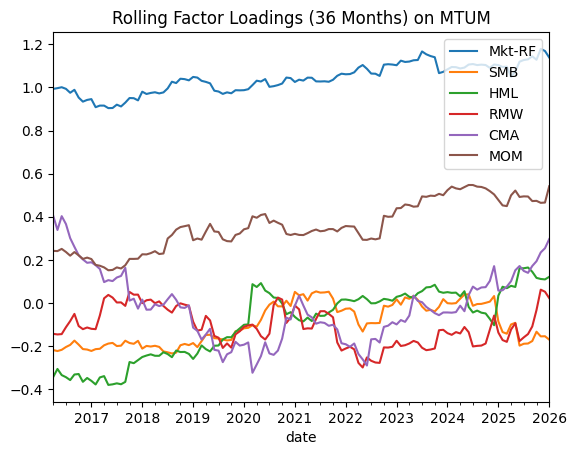

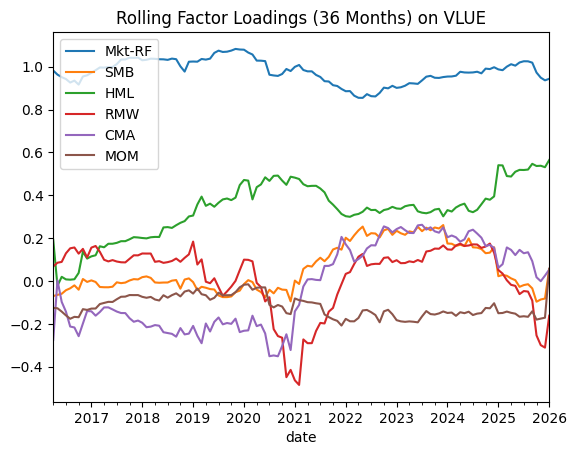

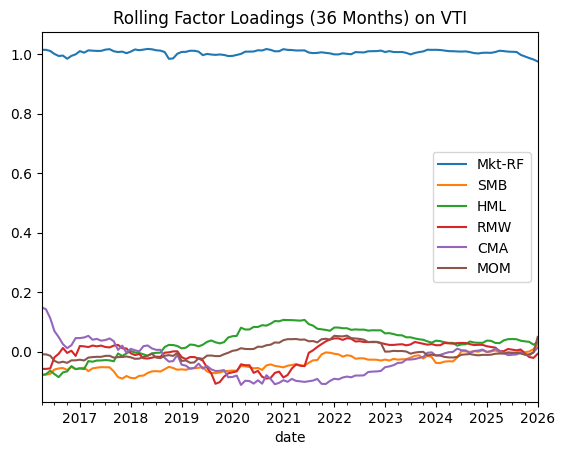

In [7]:
roll_window = 36

results = rolling_factor_regression(rets, ff_6_factor_model, roll_window)

for ticker in results:
    results[ticker].plot(title=f'Rolling Factor Loadings ({roll_window} Months) on {ticker}')